**In the previous notebook I have used 6 machine learning models and got 97.5% accuracy on test data(submission). iN THIS NOTEBOOK I will be using SVM and check its accuracy on train data after that i will be using PCA to extract the useful features and the again will use SVM. Let's do this 😀**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [2]:
train=pd.read_csv('../input/digit-recognizer/train.csv')
test=pd.read_csv('../input/digit-recognizer/test.csv')


In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


**Looking Shape of both traing and test data**

In [6]:
print('Shape of train data {} and shape of test data {}'.format(train.shape,test.shape))

Shape of train data (42000, 785) and shape of test data (28000, 784)


**Looking for nan values**

In [7]:
train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [8]:
test.isnull().sum()

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 784, dtype: int64

**Plotting digits**

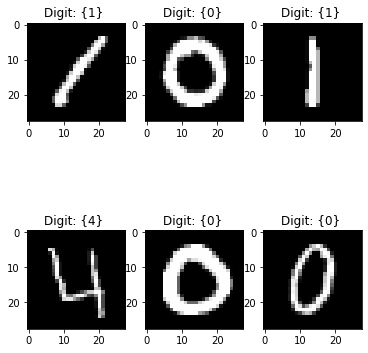

In [9]:
fig,ax = plt.subplots(2,3,figsize=(6,7))
ax = ax.flatten()
for i in range(6):
    ax[i].imshow(train.iloc[i,1:].to_numpy().reshape(28,28),cmap='gray')
    ax[i].set_title('Digit: {} '.format({train.iloc[i,0]}))

**Visualizing total count for each digit**

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


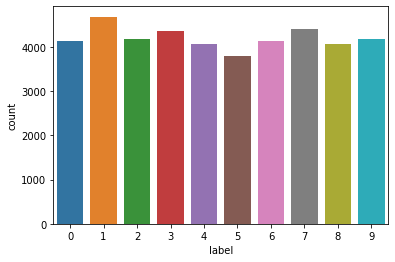

In [10]:
sns.countplot('label',data=train)
plt.show()

In [11]:
X=train.drop('label',axis=1)
y=train['label']

**Saving Index of each image**

> This is for submission purpose.



In [12]:
imageid=(test.index)+1
imageid

RangeIndex(start=1, stop=28001, step=1)

**Scaling our data as we know PCA works well on scaled data**

> Dividing by 255 as in our data values are in bw 0-255.



In [13]:
x_Scale=X/255
test_scale=test/255

**SupportVectorMachine (SVM)**

In [14]:
svm=SVC()
svm.fit(x_Scale,y)
svm.score(x_Scale,y)

0.9891428571428571

**PCA** 

Extracting those features which contains **95 percent** information or variation.

In [15]:
pca=PCA(0.95)
x_pca=pca.fit_transform(x_Scale)


**Checking shape of PCA components**

In [16]:
x_pca.shape

(42000, 154)

**Transforming test data**

In [17]:
test=pca.transform(test_scale)

**looking for shape of transformed data**

In [18]:
test.shape

(28000, 154)

**SVM**

In [19]:
svm1=SVC()
svm1.fit(x_pca,y)
svm1.score(x_pca,y)

0.9925952380952381

We can see Our accuracy imporved 😎. Previously my score was 97.5% on test data after submission now **I got ~=98% accuracy** :

In [20]:
#ypred=svm1.predict(test)

In [21]:
#ypred[:5]

**Making csv file for submission**

In [22]:
# df=pd.DataFrame({'ImageId':imageid,'Label':ypred})
# df.to_csv('file.csv',index=False)
# df.head()